In [1]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def generate_guassian(mu,sigma2,n):
    sigma=math.sqrt(sigma2)
    sample=[]
    while len(sample)<n:
        u1=2*random.random()-1
        u2=2*random.random()-1
        s=u1*u1+u2*u2
        if 0<s<1:
            k=math.sqrt(-2*math.log(s)/s)
            z1=u1*k
            z2=u2*k
            x1=mu+sigma*z1
            x2=mu+sigma*z2
            sample.append(x1)
            if len(sample)<n:
                sample.append(x2)
    return sample

In [3]:
n=5000
mu1=2
mu2=5
sigma2=1
d1=generate_guassian(mu1,sigma2,n)
d2=generate_guassian(mu2,sigma2,n)
print(d1[:5])
print(d2[:5])

[1.95540076465638, 2.3579967945884386, 1.6389500249065532, 3.2771866876688622, 1.5336287475157449]
[6.272157844207364, 4.995732976730991, 4.244434486286357, 3.931317009280954, 4.517103123553039]


In [4]:
x=np.column_stack((d1,d2))
print(x.shape)
print(x[:5])


(5000, 2)
[[1.95540076 6.27215784]
 [2.35799679 4.99573298]
 [1.63895002 4.24443449]
 [3.27718669 3.93131701]
 [1.53362875 4.51710312]]


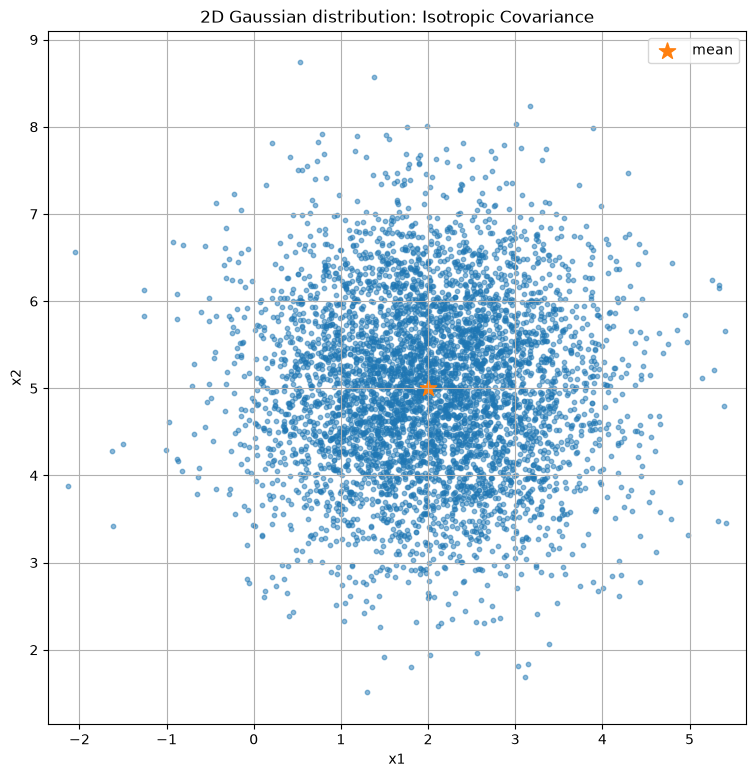

In [5]:
plt.figure(figsize=(9,9))
plt.scatter(x[:,0],x[:,1],alpha=0.5,s=10)
plt.scatter(mu1,mu2,marker="*",s=150,label="mean")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("2D Gaussian distribution: Isotropic Covariance")
plt.axis("equal")
plt.grid()
plt.legend()
plt.show()

In [6]:
mu_estimated=np.mean(x,axis=0)
sigma_estimated=np.cov(x,rowvar=False)
print("Estimated mean:", mu_estimated)
print("Estimated covariance matrix:\n", sigma_estimated)

Estimated mean: [2.01225254 5.01195705]
Estimated covariance matrix:
 [[ 9.96497139e-01 -9.87930811e-04]
 [-9.87930811e-04  9.96753398e-01]]


In [7]:
eigenvalues,eigenvectors=np.linalg.eigh(sigma_estimated)
order=np.argsort(eigenvalues)[::-1]
eigenvalues=eigenvalues[order]
eigenvectors=eigenvectors[:,order]
print("Eigenvalues:",eigenvalues)
print("Eigenvectors:\n",eigenvectors)
print("Major semi-axis length:",np.sqrt(eigenvalues[0]))
print("minor semi-axis length:",np.sqrt(eigenvalues[1]))

Eigenvalues: [0.99762147 0.99562906]
Eigenvectors:
 [[-0.6600691  -0.75120489]
 [ 0.75120489 -0.6600691 ]]
Major semi-axis length: 0.9988100288930808
minor semi-axis length: 0.997812138516555


In [8]:
sigma_inverse=np.linalg.inv(sigma_estimated)
x1_values=np.linspace(x[:,0].min()-1,x[:,0].max()+1,300)
x2_values=np.linspace(x[:,1].min()-1,x[:,1].max()+1,300)
xx,yy=np.meshgrid(x1_values,x2_values)
distance=np.zeros_like(xx)
for i in range(xx.shape[0]):
    for j in range(xx.shape[1]):
        point=np.array([xx[i,j],yy[i,j]])
        difference=point-mu_estimated
        distance[i,j]=(difference.T @ sigma_inverse @ difference)

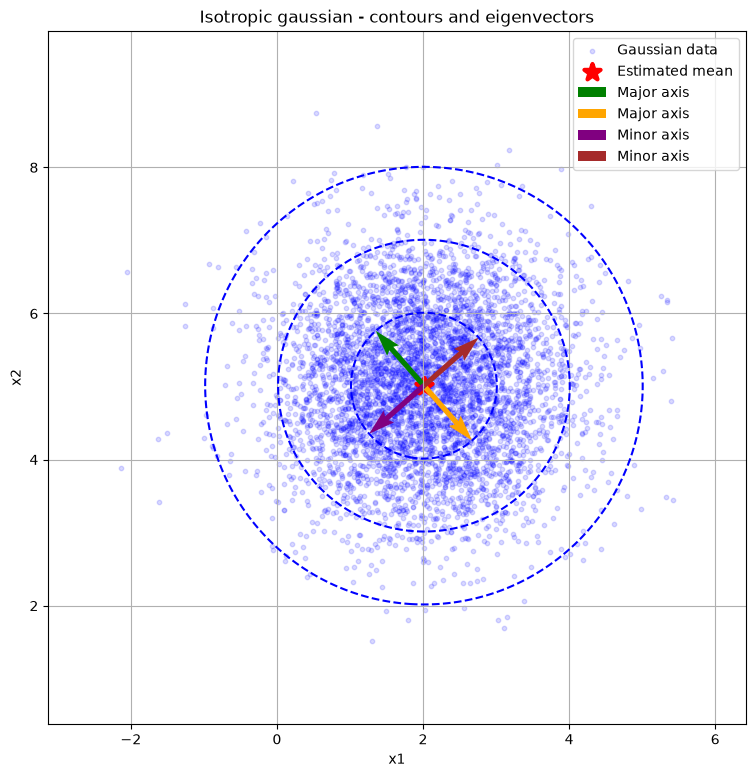

In [9]:
plt.figure(figsize=(9,9))
plt.scatter(x[:,0],x[:,1],color="blue",alpha=0.15,s=10,label="Gaussian data")
plt.contour(xx,yy,distance,levels=[1,4,9],colors="blue",linestyles="dashed")
plt.scatter(mu_estimated[0],mu_estimated[1],marker="*",s=150,color="red",linewidths=3,label="Estimated mean")
v1=eigenvectors[:,0]*np.sqrt(eigenvalues[0])
plt.quiver(mu_estimated[0],mu_estimated[1],v1[0],v1[1],angles="xy",scale_units="xy",scale=1,color="green",label="Major axis")
plt.quiver(mu_estimated[0],mu_estimated[1],-v1[0],-v1[1],angles="xy",scale_units="xy",scale=1,color="orange",label="Major axis")

v2=eigenvectors[:,1]*np.sqrt(eigenvalues[1])
plt.quiver(mu_estimated[0],mu_estimated[1],v2[0],v2[1],angles="xy",scale_units="xy",scale=1,color="purple",label="Minor axis")
plt.quiver(mu_estimated[0],mu_estimated[1],-v2[0],-v2[1],angles="xy",scale_units="xy",scale=1,color="brown",label="Minor axis")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Isotropic gaussian - contours and eigenvectors")
plt.axis("equal")
plt.grid()
plt.legend()
plt.show()

In [10]:
sigma_diagonal=np.array([[4.0,0.0],[0.0,1.0]])
print(sigma_diagonal)

[[4. 0.]
 [0. 1.]]


In [11]:
sigma_half=np.array([[2.0,0.0],[0.0,1.0]])
print(sigma_half)
print(sigma_half @ sigma_half)

[[2. 0.]
 [0. 1.]]
[[4. 0.]
 [0. 1.]]


In [12]:
mu=np.array([mu1,mu2])
y_diagonal=np.zeros_like(x)
for i in range(len(x)):
    centered=x[i]-mu
    transformed=sigma_half @ centered
    y_diagonal[i]=transformed+mu

In [13]:
mu_diagonal=np.mean(y_diagonal,axis=0)
sigma_diagonal_estimated=np.cov(y_diagonal,rowvar=False)
print("estimated mean:",mu_diagonal)
print("target covariance:",sigma_diagonal)
print("estimated covariance:",sigma_diagonal_estimated)

estimated mean: [2.02450507 5.01195705]
target covariance: [[4. 0.]
 [0. 1.]]
estimated covariance: [[ 3.98598856e+00 -1.97586162e-03]
 [-1.97586162e-03  9.96753398e-01]]


In [14]:
eigval_diag,eigvec_diag=np.linalg.eigh(sigma_diagonal_estimated)
order=np.argsort(eigval_diag)[::-1]
eigval_diag=eigval_diag[order]
eigvec_diag=eigvec_diag[:, order]
print("Eigenvalues:",eigval_diag)
print("Eigenvectors:\n",eigvec_diag)
print("Major semi-axis:",np.sqrt(eigval_diag[0]))
print("Minor semi-axis:",np.sqrt(eigval_diag[1]))

Eigenvalues: [3.98598986 0.99675209]
Eigenvectors:
 [[-9.99999782e-01 -6.60991933e-04]
 [ 6.60991933e-04 -9.99999782e-01]]
Major semi-axis: 1.996494393511291
Minor semi-axis: 0.9983747253592781


In [15]:
sigma_diag_inverse=np.linalg.inv(sigma_diagonal_estimated)
x1_values=np.linspace(y_diagonal[:,0].min()-1,y_diagonal[:,0].max()+1,300)
x2_values=np.linspace(y_diagonal[:,1].min()-1,y_diagonal[:,1].max()+1,300)
xx,yy=np.meshgrid(x1_values,x2_values)
distance_diag=np.zeros_like(xx)
for i in range(xx.shape[0]):
    for j in range(xx.shape[1]):
        point=np.array([xx[i,j],yy[i,j]])
        difference=point-mu_diagonal
        distance_diag[i,j]=(difference.T @ sigma_diag_inverse @ difference)

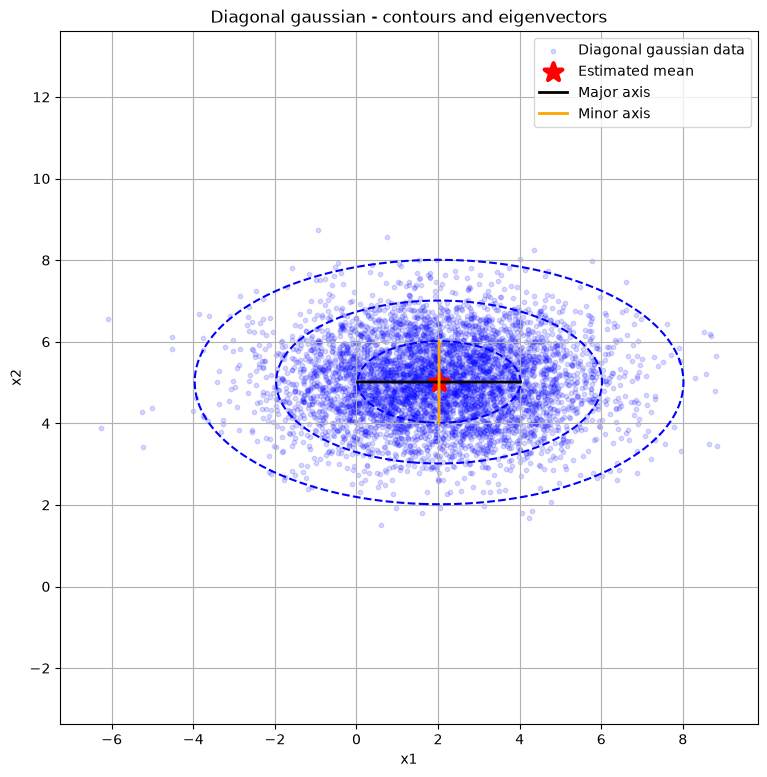

In [16]:
plt.figure(figsize=(9,9))
plt.scatter(y_diagonal[:,0],y_diagonal[:,1],color="blue",alpha=0.15,s=10,label="Diagonal gaussian data")
plt.contour(xx,yy,distance_diag,levels=[1,4,9],colors="blue",linestyles="dashed")
plt.scatter(mu_diagonal[0],mu_diagonal[1],marker="*",s=180,color="red",linewidths=3,label="Estimated mean")
v1=eigvec_diag[:,0]*np.sqrt(eigval_diag[0])
plt.plot([mu_diagonal[0]-v1[0], mu_diagonal[0]+v1[0]], [mu_diagonal[1]-v1[1], mu_diagonal[1]+v1[1]], color="black", linewidth=2, label="Major axis")

v2=eigvec_diag[:,1]*np.sqrt(eigval_diag[1])
plt.plot([mu_diagonal[0]-v2[0], mu_diagonal[0]+v2[0]], [mu_diagonal[1]-v2[1], mu_diagonal[1]+v2[1]], color="orange", linewidth=2, label="Minor axis")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Diagonal gaussian - contours and eigenvectors")
plt.axis("equal")
plt.grid()
plt.legend()
plt.show()

In [17]:
sigma_full=np.array([[4.0,1.5],[1.5,1.0]])
print("target covariance:",sigma_full)

target covariance: [[4.  1.5]
 [1.5 1. ]]


In [18]:
eigenvalues_full,eigenvectors_full=np.linalg.eigh(sigma_full)
print("Eigenvalues:",eigenvalues_full)
print("Eigenvectors:\n",eigenvectors_full)

Eigenvalues: [0.37867966 4.62132034]
Eigenvectors:
 [[ 0.38268343 -0.92387953]
 [-0.92387953 -0.38268343]]


In [19]:
lambda_half=np.diag(np.sqrt(eigenvalues_full))
print("Square root of eigenvalues:",lambda_half)

Square root of eigenvalues: [[0.61536953 0.        ]
 [0.         2.14972564]]


In [20]:
sigma_half_full=(eigenvectors_full @ lambda_half @ eigenvectors_full.T)
print("Square root of covariance matrix:\n",sigma_half_full)
print("Check: sigma_half_full @ sigma_half_full:\n",sigma_half_full @ sigma_half_full)

Square root of covariance matrix:
 [[1.92502439 0.54247681]
 [0.54247681 0.84007078]]
Check: sigma_half_full @ sigma_half_full:
 [[4.  1.5]
 [1.5 1. ]]


In [21]:
y_full=np.zeros_like(x)
for i in range(len(x)):
    centered=x[i]-mu
    transformed=sigma_half_full @ centered
    y_full[i]=transformed+mu

In [22]:
mu_full=np.mean(y_full,axis=0)
sigma_full_estimated=np.cov(y_full,rowvar=False)
print("estimated mean:",mu_full)
print("target covariance:",sigma_full)
print("estimated covariance:",sigma_full_estimated)

estimated mean: [2.03007285 5.01669149]
target covariance: [[4.  1.5]
 [1.5 1. ]]
estimated covariance: [[3.98400061 1.49297412]
 [1.49297412 0.99577755]]


In [23]:
eigval_estimated,eigvec_estimated=np.linalg.eigh(sigma_full_estimated)
order=np.argsort(eigval_estimated)[::-1]
eigval_estimated=eigval_estimated[order]
eigvec_estimated=eigvec_estimated[:, order]
print("Eigenvalues:",eigval_estimated)
print("Eigenvectors:\n",eigvec_estimated)
print("Major semi-axis:",np.sqrt(eigval_estimated[0]))
print("Minor semi-axis:",np.sqrt(eigval_estimated[1]))

Eigenvalues: [4.60207776 0.37770041]
Eigenvectors:
 [[-0.92395237  0.38250753]
 [-0.38250753 -0.92395237]]
Major semi-axis: 2.145245384053182
Minor semi-axis: 0.614573352273194


In [24]:
sigma_full_inverse=np.linalg.inv(sigma_full_estimated)
x1_values=np.linspace(y_full[:,0].min()-1,y_full[:,0].max()+1,300)
x2_values=np.linspace(y_full[:,1].min()-1,y_full[:,1].max()+1,300)
xx,yy=np.meshgrid(x1_values,x2_values)
distance_full=np.zeros_like(xx)
for i in range(xx.shape[0]):
    for j in range(xx.shape[1]):
        point=np.array([xx[i,j],yy[i,j]])
        difference=point-mu_full
        distance_full[i,j]=(difference.T @ sigma_full_inverse @ difference)

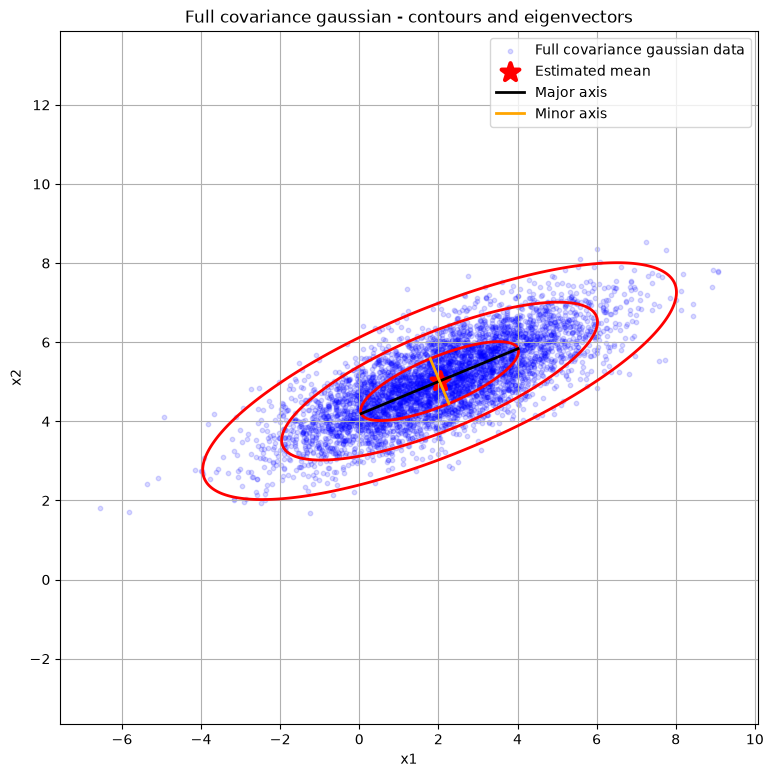

In [25]:
plt.figure(figsize=(9,9))
plt.scatter(y_full[:,0],y_full[:,1],color="blue",alpha=0.15,s=10,label="Full covariance gaussian data")
plt.contour(xx,yy,distance_full,levels=[1,4,9],colors="red",linewidths=2)
plt.scatter(mu_full[0],mu_full[1],marker="*",s=180,color="red",linewidths=3,label="Estimated mean")
v1=eigvec_estimated[:,0]*np.sqrt(eigval_estimated[0])
plt.plot([mu_full[0]-v1[0], mu_full[0]+v1[0]], [mu_full[1]-v1[1], mu_full[1]+v1[1]], color="black", linewidth=2, label="Major axis")
v2=eigvec_estimated[:,1]*np.sqrt(eigval_estimated[1])
plt.plot([mu_full[0]-v2[0], mu_full[0]+v2[0]], [mu_full[1]-v2[1], mu_full[1]+v2[1]], color="orange", linewidth=2, label="Minor axis")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Full covariance gaussian - contours and eigenvectors")
plt.axis("equal")
plt.grid()
plt.legend()
plt.show()

In [26]:
n_class=2000
mu_class1=np.array([-2.0,0.0])
sigma_class1=np.array([[1.0,0.0],[0.0,1.0]])

z11=generate_guassian(0,1,n_class)
z12=generate_guassian(0,1,n_class)

z1=np.column_stack((z11,z12))

lambda1,v1=np.linalg.eigh(sigma_class1)
lambda1_half=np.diag(np.sqrt(lambda1))
sigma1_half=v1 @ lambda1_half @ v1.T

y1=np.zeros_like(z1)
for i in range(n_class):
    y1[i]=sigma1_half @ z1[i]+mu_class1

In [27]:
mu_class2=np.array([2.0,0.0])
sigma_class2=np.array([[1.0,0.0],[0.0,1.0]])

z21=generate_guassian(0,1,n_class)
z22=generate_guassian(0,1,n_class)

z2=np.column_stack((z21,z22))

lambda2,v2=np.linalg.eigh(sigma_class2)
lambda2_half=np.diag(np.sqrt(lambda2))
sigma2_half=v2 @ lambda2_half @ v2.T

y2=np.zeros_like(z2)
for i in range(n_class):
    y2[i]=sigma2_half @ z2[i]+mu_class2

In [28]:
mu1_est=np.mean(y1,axis=0)
mu2_est=np.mean(y2,axis=0)
sigma1_est=np.cov(y1,rowvar=False)
sigma2_est=np.cov(y2,rowvar=False)
print("class 1")
print("mean:",mu1_est)
print("covariance:",sigma1_est)
print("class 2")
print("mean:",mu2_est)
print("covariance:",sigma2_est)

class 1
mean: [-1.99696039 -0.02339453]
covariance: [[1.00008392 0.02009368]
 [0.02009368 1.00566025]]
class 2
mean: [ 2.01602731 -0.00358516]
covariance: [[1.03051346 0.03092655]
 [0.03092655 1.00373816]]


In [29]:
sigma1_inverse=np.linalg.inv(sigma1_est)
sigma2_inverse=np.linalg.inv(sigma2_est)
det1=np.linalg.det(sigma1_est)
det2=np.linalg.det(sigma2_est)
p1=0.5
p2=0.5
all_data=np.vstack((y1,y2))
x_values=np.linspace(all_data[:,0].min()-1,all_data[:,0].max()+1,350)
y_values=np.linspace(all_data[:,1].min()-1,all_data[:,1].max()+1,350)
xx,yy=np.meshgrid(x_values,y_values)
distance1=np.zeros_like(xx)
distance2=np.zeros_like(xx)
decision_boundary=np.zeros_like(xx)

for i in range(xx.shape[0]):
    for j in range(xx.shape[1]):
        point=np.array([xx[i,j],yy[i,j]])
        difference1=point-mu1_est
        difference2=point-mu2_est
        distance1[i,j]=(difference1.T @ sigma1_inverse @ difference1)
        distance2[i,j]=(difference2.T @ sigma2_inverse @ difference2)
        g1=-0.5*distance1[i,j]-0.5*np.log(det1)+np.log(p1)
        g2=-0.5*distance2[i,j]-0.5*np.log(det2)+np.log(p2)
        decision_boundary[i,j]=g1-g2

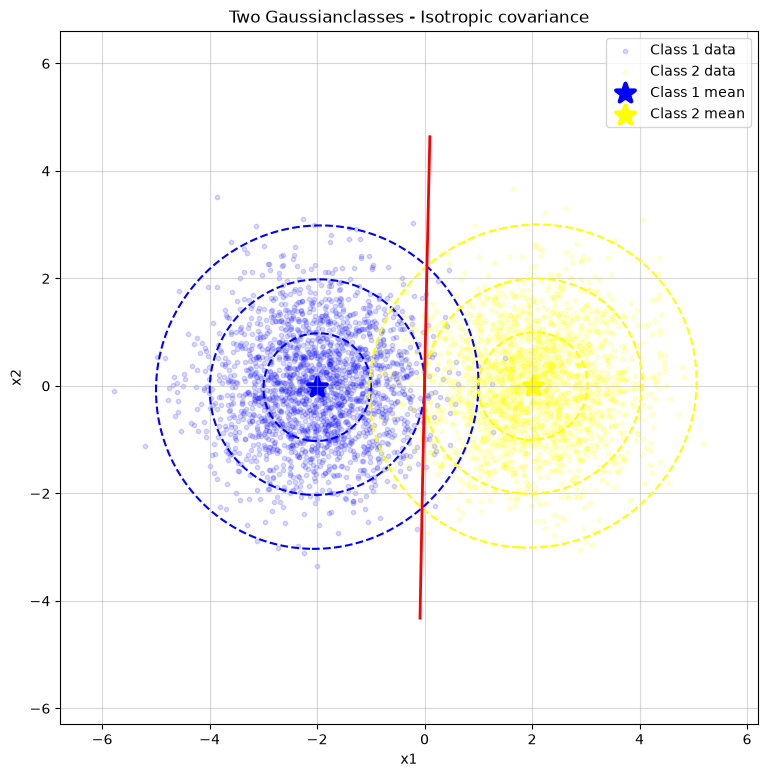

In [30]:
plt.figure(figsize=(9,9))
plt.scatter(y1[:,0],y1[:,1],color="blue",alpha=0.15,s=10,label="Class 1 data")
plt.scatter(y2[:,0],y2[:,1],color="yellow",alpha=0.15,s=10,label="Class 2 data")
plt.contour(xx,yy,distance1,levels=[1,4,9],colors="blue",linestyles="dashed")
plt.contour(xx,yy,distance2,levels=[1,4,9],colors="yellow",linestyles="dashed")
plt.contour(xx,yy,decision_boundary,levels=[0],colors="red",linewidths=2)
plt.scatter(mu1_est[0],mu1_est[1],marker="*",s=200,color="blue",linewidths=3,label="Class 1 mean")
plt.scatter(mu2_est[0],mu2_est[1],marker="*",s=200,color="yellow",linewidths=3,label="Class 2 mean")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Two Gaussianclasses - Isotropic covariance")
plt.axis("equal")
plt.grid(alpha=0.5)
plt.legend()
plt.show()

In [31]:
n_class=2000
mu_class1=np.array([-2.0,0.0])
sigma_class1=np.array([[4.0,0.0],[0.0,1.0]])

z11=generate_guassian(0,1,n_class)
z12=generate_guassian(0,1,n_class)

z1=np.column_stack((z11,z12))

lambda1,v1=np.linalg.eigh(sigma_class1)
lambda1_half=np.diag(np.sqrt(lambda1))
sigma1_half=v1 @ lambda1_half @ v1.T

y1=np.zeros_like(z1)
for i in range(n_class):
    y1[i]=sigma1_half @ z1[i]+mu_class1

In [32]:
mu_class2=np.array([2.0,0.0])
sigma_class2=np.array([[1.0,0.0],[0.0,4.0]])

z21=generate_guassian(0,1,n_class)
z22=generate_guassian(0,1,n_class)

z2=np.column_stack((z21,z22))

lambda2,v2=np.linalg.eigh(sigma_class2)
lambda2_half=np.diag(np.sqrt(lambda2))
sigma2_half=v2 @ lambda2_half @ v2.T

y2=np.zeros_like(z2)
for i in range(n_class):
    y2[i]=sigma2_half @ z2[i]+mu_class2

In [33]:
mu1_est=np.mean(y1,axis=0)
mu2_est=np.mean(y2,axis=0)
sigma1_est=np.cov(y1,rowvar=False)
sigma2_est=np.cov(y2,rowvar=False)
print("class 1")
print("mean:",mu1_est)
print("covariance:",sigma1_est)
print("class 2")
print("mean:",mu2_est)
print("covariance:",sigma2_est)

class 1
mean: [-1.97609001  0.01525216]
covariance: [[ 3.83770842 -0.0250629 ]
 [-0.0250629   0.99810041]]
class 2
mean: [ 1.99532015 -0.00318022]
covariance: [[ 0.94160915 -0.00988433]
 [-0.00988433  4.14343751]]


In [34]:
sigma1_inverse=np.linalg.inv(sigma1_est)
sigma2_inverse=np.linalg.inv(sigma2_est)
det1=np.linalg.det(sigma1_est)
det2=np.linalg.det(sigma2_est)
p1=0.5
p2=0.5
all_data=np.vstack((y1,y2))
x_values=np.linspace(all_data[:,0].min()-1,all_data[:,0].max()+1,350)
y_values=np.linspace(all_data[:,1].min()-1,all_data[:,1].max()+1,350)
xx,yy=np.meshgrid(x_values,y_values)
distance1=np.zeros_like(xx)
distance2=np.zeros_like(xx)
decision_boundary=np.zeros_like(xx)

for i in range(xx.shape[0]):
    for j in range(xx.shape[1]):
        point=np.array([xx[i,j],yy[i,j]])
        difference1=point-mu1_est
        difference2=point-mu2_est
        distance1[i,j]=(difference1.T @ sigma1_inverse @ difference1)
        distance2[i,j]=(difference2.T @ sigma2_inverse @ difference2)
        g1=-0.5*distance1[i,j]-0.5*np.log(det1)+np.log(p1)
        g2=-0.5*distance2[i,j]-0.5*np.log(det2)+np.log(p2)
        decision_boundary[i,j]=g1-g2

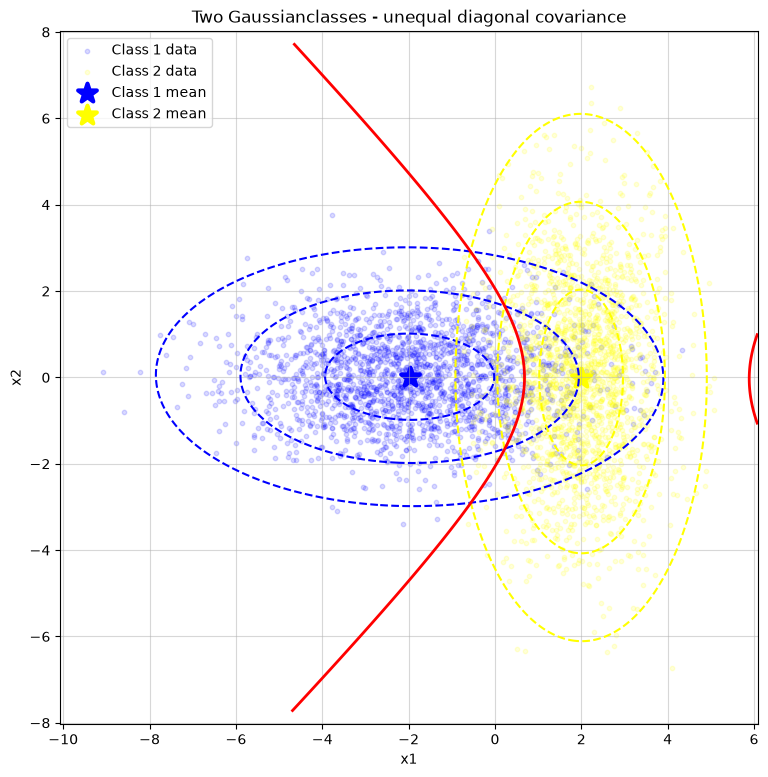

In [35]:
plt.figure(figsize=(9,9))
plt.scatter(y1[:,0],y1[:,1],color="blue",alpha=0.15,s=10,label="Class 1 data")
plt.scatter(y2[:,0],y2[:,1],color="yellow",alpha=0.15,s=10,label="Class 2 data")
plt.contour(xx,yy,distance1,levels=[1,4,9],colors="blue",linestyles="dashed")
plt.contour(xx,yy,distance2,levels=[1,4,9],colors="yellow",linestyles="dashed")
plt.contour(xx,yy,decision_boundary,levels=[0],colors="red",linewidths=2)
plt.scatter(mu1_est[0],mu1_est[1],marker="*",s=200,color="blue",linewidths=3,label="Class 1 mean")
plt.scatter(mu2_est[0],mu2_est[1],marker="*",s=200,color="yellow",linewidths=3,label="Class 2 mean")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Two Gaussianclasses - unequal diagonal covariance")
plt.axis("equal")
plt.grid(alpha=0.5)
plt.legend()
plt.show()

In [36]:
n_class=2000
mu_class1=np.array([-2.0,0.0])
sigma_class1=np.array([[3.0,1.5],[1.5,1.5]])

z11=generate_guassian(0,1,n_class)
z12=generate_guassian(0,1,n_class)

z1=np.column_stack((z11,z12))

lambda1,v1=np.linalg.eigh(sigma_class1)
lambda1_half=np.diag(np.sqrt(lambda1))
sigma1_half=v1 @ lambda1_half @ v1.T

y1=np.zeros_like(z1)
for i in range(n_class):
    y1[i]=sigma1_half @ z1[i]+mu_class1

In [37]:
mu_class2=np.array([2.0,0.0])
sigma_class2=np.array([[3.0,1.5],[1.5,1.5]])

z21=generate_guassian(0,1,n_class)
z22=generate_guassian(0,1,n_class)

z2=np.column_stack((z21,z22))

lambda2,v2=np.linalg.eigh(sigma_class2)
lambda2_half=np.diag(np.sqrt(lambda2))
sigma2_half=v2 @ lambda2_half @ v2.T

y2=np.zeros_like(z2)
for i in range(n_class):
    y2[i]=sigma2_half @ z2[i]+mu_class2

In [38]:
mu1_est=np.mean(y1,axis=0)
mu2_est=np.mean(y2,axis=0)
sigma1_est=np.cov(y1,rowvar=False)
sigma2_est=np.cov(y2,rowvar=False)
print("class 1")
print("mean:",mu1_est)
print("covariance:",sigma1_est)
print("class 2")
print("mean:",mu2_est)
print("covariance:",sigma2_est)

class 1
mean: [-1.98065999  0.03622343]
covariance: [[3.01420152 1.52436634]
 [1.52436634 1.53864311]]
class 2
mean: [1.98801217 0.01685324]
covariance: [[3.12690375 1.5377841 ]
 [1.5377841  1.50388917]]


In [39]:
sigma1_inverse=np.linalg.inv(sigma1_est)
sigma2_inverse=np.linalg.inv(sigma2_est)
det1=np.linalg.det(sigma1_est)
det2=np.linalg.det(sigma2_est)
p1=0.5
p2=0.5
all_data=np.vstack((y1,y2))
x_values=np.linspace(all_data[:,0].min()-1,all_data[:,0].max()+1,350)
y_values=np.linspace(all_data[:,1].min()-1,all_data[:,1].max()+1,350)
xx,yy=np.meshgrid(x_values,y_values)
distance1=np.zeros_like(xx)
distance2=np.zeros_like(xx)
decision_boundary=np.zeros_like(xx)

for i in range(xx.shape[0]):
    for j in range(xx.shape[1]):
        point=np.array([xx[i,j],yy[i,j]])
        difference1=point-mu1_est
        difference2=point-mu2_est
        distance1[i,j]=(difference1.T @ sigma1_inverse @ difference1)
        distance2[i,j]=(difference2.T @ sigma2_inverse @ difference2)
        g1=-0.5*distance1[i,j]-0.5*np.log(det1)+np.log(p1)
        g2=-0.5*distance2[i,j]-0.5*np.log(det2)+np.log(p2)
        decision_boundary[i,j]=g1-g2

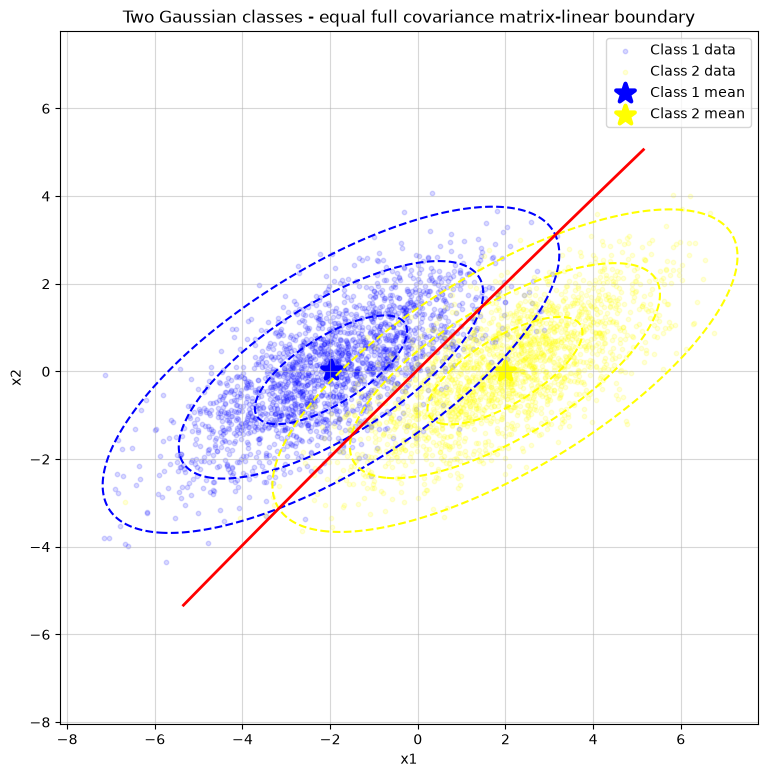

In [40]:
plt.figure(figsize=(9,9))
plt.scatter(y1[:,0],y1[:,1],color="blue",alpha=0.15,s=10,label="Class 1 data")
plt.scatter(y2[:,0],y2[:,1],color="yellow",alpha=0.15,s=10,label="Class 2 data")
plt.contour(xx,yy,distance1,levels=[1,4,9],colors="blue",linestyles="dashed")
plt.contour(xx,yy,distance2,levels=[1,4,9],colors="yellow",linestyles="dashed")
plt.contour(xx,yy,decision_boundary,levels=[0],colors="red",linewidths=2)
plt.scatter(mu1_est[0],mu1_est[1],marker="*",s=200,color="blue",linewidths=3,label="Class 1 mean")
plt.scatter(mu2_est[0],mu2_est[1],marker="*",s=200,color="yellow",linewidths=3,label="Class 2 mean")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Two Gaussian classes - equal full covariance matrix-linear boundary")
plt.axis("equal")
plt.grid(alpha=0.5)
plt.legend()
plt.show()

In [41]:
n_class=2000
mu_class1=np.array([-2.0,0.0])
sigma_class1=np.array([[3.0,1.5],[1.5,1.5]])

z11=generate_guassian(0,1,n_class)
z12=generate_guassian(0,1,n_class)

z1=np.column_stack((z11,z12))

lambda1,v1=np.linalg.eigh(sigma_class1)
lambda1_half=np.diag(np.sqrt(lambda1))
sigma1_half=v1 @ lambda1_half @ v1.T

y1=np.zeros_like(z1)
for i in range(n_class):
    y1[i]=sigma1_half @ z1[i]+mu_class1

In [42]:
mu_class2=np.array([2.0,0.0])
sigma_class2=np.array([[3.0,-1.5],[-1.5,1.5]])

z21=generate_guassian(0,1,n_class)
z22=generate_guassian(0,1,n_class)

z2=np.column_stack((z21,z22))

lambda2,v2=np.linalg.eigh(sigma_class2)
lambda2_half=np.diag(np.sqrt(lambda2))
sigma2_half=v2 @ lambda2_half @ v2.T

y2=np.zeros_like(z2)
for i in range(n_class):
    y2[i]=sigma2_half @ z2[i]+mu_class2

In [43]:
mu1_est=np.mean(y1,axis=0)
mu2_est=np.mean(y2,axis=0)
sigma1_est=np.cov(y1,rowvar=False)
sigma2_est=np.cov(y2,rowvar=False)
print("class 1")
print("mean:",mu1_est)
print("covariance:",sigma1_est)
print("class 2")
print("mean:",mu2_est)
print("covariance:",sigma2_est)

class 1
mean: [-2.00744719 -0.03081364]
covariance: [[3.15727352 1.58403153]
 [1.58403153 1.57141116]]
class 2
mean: [ 2.13084803 -0.09072076]
covariance: [[ 2.93463465 -1.49748798]
 [-1.49748798  1.47232257]]


In [44]:
sigma1_inverse=np.linalg.inv(sigma1_est)
sigma2_inverse=np.linalg.inv(sigma2_est)
det1=np.linalg.det(sigma1_est)
det2=np.linalg.det(sigma2_est)
p1=0.5
p2=0.5
all_data=np.vstack((y1,y2))
x_values=np.linspace(all_data[:,0].min()-1,all_data[:,0].max()+1,350)
y_values=np.linspace(all_data[:,1].min()-1,all_data[:,1].max()+1,350)
xx,yy=np.meshgrid(x_values,y_values)
distance1=np.zeros_like(xx)
distance2=np.zeros_like(xx)
decision_boundary=np.zeros_like(xx)

for i in range(xx.shape[0]):
    for j in range(xx.shape[1]):
        point=np.array([xx[i,j],yy[i,j]])
        difference1=point-mu1_est
        difference2=point-mu2_est
        distance1[i,j]=(difference1.T @ sigma1_inverse @ difference1)
        distance2[i,j]=(difference2.T @ sigma2_inverse @ difference2)
        g1=-0.5*distance1[i,j]-0.5*np.log(det1)+np.log(p1)
        g2=-0.5*distance2[i,j]-0.5*np.log(det2)+np.log(p2)
        decision_boundary[i,j]=g1-g2

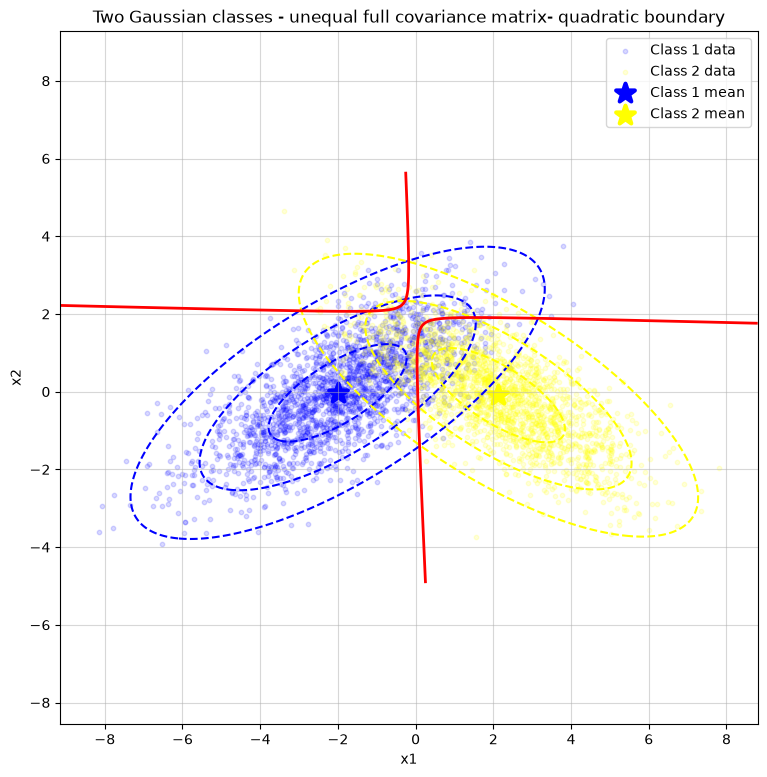

In [45]:
plt.figure(figsize=(9,9))
plt.scatter(y1[:,0],y1[:,1],color="blue",alpha=0.15,s=10,label="Class 1 data")
plt.scatter(y2[:,0],y2[:,1],color="yellow",alpha=0.15,s=10,label="Class 2 data")
plt.contour(xx,yy,distance1,levels=[1,4,9],colors="blue",linestyles="dashed")
plt.contour(xx,yy,distance2,levels=[1,4,9],colors="yellow",linestyles="dashed")
plt.contour(xx,yy,decision_boundary,levels=[0],colors="red",linewidths=2)
plt.scatter(mu1_est[0],mu1_est[1],marker="*",s=200,color="blue",linewidths=3,label="Class 1 mean")
plt.scatter(mu2_est[0],mu2_est[1],marker="*",s=200,color="yellow",linewidths=3,label="Class 2 mean")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Two Gaussian classes - unequal full covariance matrix- quadratic boundary")
plt.axis("equal")
plt.grid(alpha=0.5)
plt.legend()
plt.show()